## Q11

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

In [306]:
''' 
    Set Up for Simulation 1 (psi is a particular value)

'''
# Simulation parameters
np.random.seed(42)
r = 0
mu = 0
S0 = 100
B0 = 1
sigma = 0.20
theta_0 = 30
b_0 = 0
b = -100
beta = 0.28
alpha = 0.5
phi = 1
gamma = 0.2
zeta = 0.25

#Time
dt = 8 / (365 * 24 * 1)  # daily
T = 1  # total time in years
N = int(T / dt) 
M = 3  # number of paths
quarter_len = int(0.25 / dt)  # 每季度步数
opex_indices = [0, quarter_len, 2 * quarter_len, 3 * quarter_len, N]






## Functions for Q11


In [311]:
''' 
    Calculation Functions 
'''
    
def bs_put_price(S, K, T, sigma, r=0):
    try:
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    except ZeroDivisionError:

        return 0.0
    
def bs_call_price(S, K, T, sigma, r =0):
    try:
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    except ZeroDivisionError:
        return 0.0
    
def bs_delta(S, K, T, sigma, option_type='call', r=0):
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    if option_type == 'call':
        return norm.cdf(d1)
    else:
        return norm.cdf(d1) - 1
    
def bs_gamma(S, K, T, sigma, r=0):
    """
    Black–Scholes Gamma: ∂²C/∂S²
    """
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0
    # compute d1
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    # gamma formula
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_charm(S, K, T, sigma, r=0):
    """
    Black–Scholes Charm: ∂²C/∂t∂S = ∂(Delta)/∂t
    For r=0 simplifies to: -φ(d1)*d2/(2*T)
    """
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0
    # compute d1, d2
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    # charm formula
    return -norm.pdf(d1) * d2 / (2 * T)

def bs_speed(S, K, T, sigma, r=0):
    """
    Black–Scholes Speed: ∂³C/∂S³ = ∂(Gamma)/∂S
    Simplified finite formula:
      ∂Γ/∂S = -d1*φ(d1)/(S² σ² T) - φ(d1)/(S² σ √T)
    """
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0
    # compute d1
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)
    pdf_d1 = norm.pdf(d1)
    term1 = -d1 * pdf_d1 / (S**2 * sigma**2 * T)
    term2 = -pdf_d1 / (S**2 * sigma * sqrtT)
    return term1 + term2

In [194]:
def dDeltaCalc(S_t, sigma, K, T):

    def bs_delta(S, K, T, sigma, option_type='call', r=0):
        if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
            return 0.0
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        if option_type == 'call':
            return norm.cdf(d1)
        else:
            return norm.cdf(d1) - 1
    
    def bs_gamma(S, K, T, sigma, r=0):
        """
        Black–Scholes Gamma: ∂²C/∂S²
        """
        if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
            return 0.0
        # compute d1
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        # gamma formula
        return norm.pdf(d1) / (S * sigma * np.sqrt(T))

    def bs_charm(S, K, T, sigma, r=0):
        """
        Black–Scholes Charm: ∂²C/∂t∂S = ∂(Delta)/∂t
        For r=0 simplifies to: -φ(d1)*d2/(2*T)
        """
        if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
            return 0.0
        # compute d1, d2
        sqrtT = np.sqrt(T)
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)
        d2 = d1 - sigma * sqrtT
        # charm formula
        return -norm.pdf(d1) * d2 / (2 * T)

    def bs_speed(S, K, T, sigma, r=0):
        """
        Black–Scholes Speed: ∂³C/∂S³ = ∂(Gamma)/∂S
        Simplified finite formula:
        ∂Γ/∂S = -d1*φ(d1)/(S² σ² T) - φ(d1)/(S² σ √T)
        """
        if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
            return 0.0
        # compute d1
        sqrtT = np.sqrt(T)
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)
        pdf_d1 = norm.pdf(d1)
        term1 = -d1 * pdf_d1 / (S**2 * sigma**2 * T)
        term2 = -pdf_d1 / (S**2 * sigma * sqrtT)
        return term1 + term2

    #2nd and 3rd Order Greeks 
    gamma = bs_gamma(S_t, K, T, sigma)
    charm = bs_charm(S_t, K, T, sigma)
    speed = bs_speed(S_t, K, T, sigma)
    
    return gamma, charm, speed

In [195]:
def simulate_full_paths(S0, b_0, sigma, psi, zeta, phi, theta_0, b,
                        dt, N, M, opex_indices, asset_type='NVDA'):

    '''
    N : number of simulations
    M : number of time steps
    theta_0 : Number of Puts and Calls bought (option size)
    '''
    #Stock Price
    S = np.zeros((M, N + 1))
    S[:, 0] = S0
    dDelta = np.zeros((M, N))
    M_t = np.zeros((M, N))
    delta_t = np.zeros((M, N + 1))


    #Greeks
    charm = np.zeros((M, N))
    speed = np.zeros((M, N))
    gamma_greek = np.zeros((M, N))

    #MMA



    #Number of Options

    K_call = np.zeros((M, len(opex_indices)))
    K_put = np.zeros((M, len(opex_indices)))
    b_t_I = np.zeros((M, len(opex_indices)+1))
    b_t_I[:, 0] = b_0
    portfolio_value = np.zeros((M, N))
    portfolio_value[:, 0] = abs(b)
    exp_phi_dt = np.exp(-phi * dt)  # Precompute exp(-phi * dt) for efficiency

    #Opex Date Logic
    T_remain = 0.25
    sqrt_remain = np.sqrt(T_remain)
    sqrt_dt = np.sqrt(dt)

    for path in range(M):
        for t in range(N + 1):
            if t == 0:
                #Opex idx counter
                idx = 0
                S_t = S0
                #Strike Price
                K_call[path, 0] = S0 * np.exp(sigma * sqrt_remain)
                K_put[path, 0] = S0 * np.exp(-sigma * sqrt_remain)

                #Black Sholes Price
                put_price = bs_put_price(S=S0, K=K_put[path, 0], T=T_remain, sigma=sigma)
                call_price = bs_call_price(S=S0, K=K_call[path, 0], T=T_remain, sigma=sigma)

                #Stock Process
                delta_call = bs_delta(S0, K_call[path, 0], T_remain, sigma, 'call')
                delta_put = bs_delta(S0, K_put[path, 0], T_remain, sigma, 'put')

                theta_t = theta_0

                b_t_I[path, 1] = b_0 - theta_0*(put_price + call_price)
                dDelta[path,0]= (delta_put + delta_call)*theta_0

                prev_delta = theta_0 * (1+delta_put + delta_call)
                portfolio_value [path, 0] = S0*theta_0

            if t > 0 and t not in opex_indices:
                delta_t[path, t] = prev_delta
                M_prev = M_t[path, t-2] if t > 1 else 0.0
                last_opex_t = max([i for i in opex_indices if i < t])
                tau = T_remain - (t - last_opex_t) * dt
                tau = max(tau, 1e-6)
                # Calculate the feedback and diffusion terms

                # 1. Calculate dDelta
                Call_Gamma, Call_Charm, Call_Speed = dDeltaCalc(
                                         S_t = S_t,
                                         sigma = sigma,
                                         K = K_call[path, idx],
                                         T = tau)
                # For Put
                Put_Gamma, Put_Charm, Put_Speed = dDeltaCalc(
                                         S_t = S_t,
                                         sigma = sigma,
                                         K = K_put[path, idx],
                                         T = tau)
                # Calculate net Greeks
                net_gamma =  (Call_Gamma + Put_Gamma)
                net_charm =  (Call_Charm + Put_Charm)
                net_speed =  (Call_Speed + Put_Speed)
                charm[path, t-1] = net_charm
                gamma_greek[path, t-1] = net_gamma
                speed[path, t-1] = net_speed
                #Calculate dDelta_dealer

                dW = np.random.normal(0, sqrt_dt)
                dt_terms = net_charm + (net_gamma * M_prev * S_t * psi) + 0.5*(net_speed*sigma**2 *S_t**(2-2*zeta))
                dW_terms = dW * sigma * S_t**(1-zeta) * net_gamma
                dDelta_Current = dt_terms*dt + dW_terms

                dDelta[path, t-1] = dDelta_Current

                # 2. Calculate M_t
                M_t[path, t-1] = exp_phi_dt * M_prev + dDelta_Current

                # 3. Calculate Diffusion
                diffusion = sigma * S_t **(1 - zeta) * dW
                # 4. Calculate Drift
                drift = psi * S_t * M_prev * dt
                # 4. Update New S_t

                S[path, t] =  diffusion + drift + S_t
                S_t = S[path, t]



            if t in opex_indices and t != 0:
                #Initial Opex Logic
                M_t[path, t-1] = 0
                idx = opex_indices.index(t)

                #New Option's Strike Price for the upcoming Period
                K_call[path, idx] = S_t * np.exp(sigma * sqrt_remain) + 0.25 * (diffusion / dW)
                K_put[path, idx] = S_t * np.exp(-sigma * sqrt_remain) - 0.25 * (diffusion / dW)
                #New Options Prices
                call_price = bs_call_price(S=S_t, K=K_call[path, idx], T=T_remain, sigma=sigma)
                put_price = bs_put_price(S=S_t, K=K_put[path, idx], T=T_remain, sigma=sigma)
                unit_cost = call_price + put_price


                #Calculate Payoff from Matured Option
                call_payoff = theta_t * max(S_t - K_call[path, idx - 1], 0)
                put_payoff = theta_t * max(K_put[path, idx - 1] - S_t, 0)


                #Update Money in MMA
                b_t = b_t_I[path, idx] + (call_payoff + put_payoff) * theta_t


                #If we are within our borrowing limits
                avaliable_money = b_t - b
                if avaliable_money >= theta_0 * (put_price + call_price):
                    theta_new = theta_0
                else:
                    theta_new = (b_t - b) / (put_price + call_price)

                #New Money in MMA
                b_t_I[path, idx+1] = b_t - theta_new * unit_cost
                #New Delta Calculations
                delta_call_new = bs_delta(S_t, K_call[path, idx], T_remain, sigma, 'call')
                delta_put_new = bs_delta(S_t, K_put[path, idx], T_remain, sigma, 'put')
                #Delta Jump [‼️i add 1 because we need to include the delta for the underlying]
                new_delta = theta_0*1 + theta_new * (delta_put_new + delta_call_new)
                dDelta[path, t - 1] = new_delta - prev_delta
                #Update Deltas
                delta_t[path, t] = new_delta
                prev_delta = new_delta
                #Portfolio value
                portfolio_value[path, idx] = theta_t * (unit_cost) + b_t_I[path, idx+1] + theta_0*S_t
                theta_t = theta_new
                S[path, t] = S_t
            #If we are not at an Opex date






    return {
        'S': pd.DataFrame(S),
        'b': pd.DataFrame(b_t_I),
        'M': pd.DataFrame(M_t),
        'dDelta': pd.DataFrame(dDelta),
        'delta': pd.DataFrame(delta_t),
        'gamma': pd.DataFrame(gamma_greek),
        'speed': pd.DataFrame(speed),
        'charm' : pd.DataFrame(charm),
        'portfolio': pd.DataFrame(portfolio_value),
        'K_call': pd.DataFrame(K_call),
        'K_put': pd.DataFrame(K_put)
    }

In [312]:
def simulate_full_paths_SPX(S0, b_0, sigma, psi, zeta, phi, theta_0, b,
                        dt, N, M, opex_indices, asset_type='SPX'):

    '''
    N : number of simulations
    M : number of time steps
    theta_0 : Number of Puts and Calls bought (option size)
    '''
    #Stock Price
    S = np.zeros((M, N + 1))
    S[:, 0] = S0
    dDelta = np.zeros((M, N))
    M_t = np.zeros((M, N))
    delta_t = np.zeros((M, N + 1))


    #Greeks
    charm = np.zeros((M, N))
    speed = np.zeros((M, N))
    gamma_greek = np.zeros((M, N))

    #MMA



    #Number of Options

    K_call = np.zeros((M, len(opex_indices)))
    K_put = np.zeros((M, len(opex_indices)))
    b_t_I = np.zeros((M, len(opex_indices)+1))
    b_t_I[:, 0] = b_0
    portfolio_value = np.zeros((M, N))
    portfolio_value[:, 0] = abs(b)
    exp_phi_dt = np.exp(-phi * dt)  # Precompute exp(-phi * dt) for efficiency

    #Opex Date Logic
    T_remain = 0.25
    sqrt_remain = np.sqrt(T_remain)
    sqrt_dt = np.sqrt(dt)

    for path in range(M):
        for t in range(N + 1):
            if t == 0:
                #Opex idx counter
                idx = 0
                S_t = S0
                #Strike Price
                K_call[path, 0] = S0 * np.exp(sigma * sqrt_remain)
                K_put[path, 0] = S0 * np.exp(-sigma * sqrt_remain)

                #Black Sholes Price
                put_price = bs_put_price(S=S0, K=K_put[path, 0], T=T_remain, sigma=sigma)
                call_price = bs_call_price(S=S0, K=K_call[path, 0], T=T_remain, sigma=sigma)

                #Stock Process
                delta_call = bs_delta(S0, K_call[path, 0], T_remain, sigma, 'call')
                delta_put = bs_delta(S0, K_put[path, 0], T_remain, sigma, 'put')

                theta_t = theta_0

                b_t_I[path, 1] = b_0 - theta_0*(put_price - call_price)
                dDelta[path,0]= (delta_put - delta_call)*theta_0

                prev_delta = theta_0 * (1+delta_put - delta_call)
                portfolio_value [path, 0] = S0*theta_0

            if t > 0 and t not in opex_indices:
                delta_t[path, t] = prev_delta
                M_prev = M_t[path, t-2] if t > 1 else 0.0
                last_opex_t = max([i for i in opex_indices if i < t])
                tau = T_remain - (t - last_opex_t) * dt
                tau = max(tau, 1e-6)
                # Calculate the feedback and diffusion terms

                # 1. Calculate dDelta
                Call_Gamma, Call_Charm, Call_Speed = dDeltaCalc(
                                         S_t = S_t,
                                         sigma = sigma,
                                         K = K_call[path, idx],
                                         T = tau)
                # For Put
                Put_Gamma, Put_Charm, Put_Speed = dDeltaCalc(
                                         S_t = S_t,
                                         sigma = sigma,
                                         K = K_put[path, idx],
                                         T = tau)
                # Calculate net Greeks
                net_gamma =  (Call_Gamma + Put_Gamma)
                net_charm =  (Call_Charm + Put_Charm)
                net_speed =  (Call_Speed + Put_Speed)
                charm[path, t-1] = net_charm
                gamma_greek[path, t-1] = net_gamma
                speed[path, t-1] = net_speed
                #Calculate dDelta_dealer

                dW = np.random.normal(0, sqrt_dt)
                dt_terms = net_charm + (net_gamma * M_prev * S_t * psi) + 0.5*(net_speed*sigma**2 *S_t**(2-2*zeta))
                dW_terms = dW * sigma * S_t**(1-zeta) * net_gamma
                dDelta_Current = dt_terms*dt + dW_terms

                dDelta[path, t-1] = dDelta_Current

                # 2. Calculate M_t
                M_t[path, t-1] = exp_phi_dt * M_prev + dDelta_Current

                # 3. Calculate Diffusion
                diffusion = sigma * S_t **(1 - zeta) * dW
                # 4. Calculate Drift
                drift = psi * S_t * M_prev * dt
                # 4. Update New S_t

                S[path, t] =  diffusion + drift + S_t
                S_t = S[path, t]



            if t in opex_indices and t != 0:
                #Initial Opex Logic
                M_t[path, t-1] = 0
                idx = opex_indices.index(t)

                #New Option's Strike Price for the upcoming Period
                K_call[path, idx] = S_t * np.exp(sigma * sqrt_remain) + 0.25 * (diffusion / dW)
                K_put[path, idx] = S_t * np.exp(-sigma * sqrt_remain) - 0.25 * (diffusion / dW)
                #New Options Prices
                call_price = bs_call_price(S=S_t, K=K_call[path, idx], T=T_remain, sigma=sigma)
                put_price = bs_put_price(S=S_t, K=K_put[path, idx], T=T_remain, sigma=sigma)



                #Calculate Payoff from Matured Option
                call_payoff = theta_t * max(S_t - K_call[path, idx - 1], 0)
                put_payoff = theta_t * max(K_put[path, idx - 1] - S_t, 0)


                #Update Money in MMA
                b_t = b_t_I[path, idx] + (-call_payoff + put_payoff) * theta_t


                #If we are within our borrowing limits
                avaliable_money = b_t - b
                if avaliable_money >= theta_0 * (put_price + call_price):
                    theta_new = theta_0
                else:
                    theta_new = (b_t - b + theta_0*call_price) / put_price

                #New Money in MMA
                b_t_I[path, idx+1] = b_t - theta_new * put_price + theta_0*call_price
                #New Delta Calculations
                delta_call_new = bs_delta(S_t, K_call[path, idx], T_remain, sigma, 'call')
                delta_put_new = bs_delta(S_t, K_put[path, idx], T_remain, sigma, 'put')
                #Delta Jump [‼️i add 1 because we need to include the delta for the underlying]
                new_delta = theta_0*1 + theta_new * (delta_put_new - delta_call_new)
                dDelta[path, t - 1] = new_delta - prev_delta
                #Update Deltas
                delta_t[path, t] = new_delta
                prev_delta = new_delta
                #Portfolio value
                portfolio_value[path, idx] = - theta_new * put_price + theta_0*call_price + b_t_I[path, idx+1] + theta_0*S_t
                theta_t = theta_new
                S[path, t] = S_t







    return {
        'S': pd.DataFrame(S),
        'b': pd.DataFrame(b_t_I),
        'M': pd.DataFrame(M_t),
        'dDelta': pd.DataFrame(dDelta),
        'delta': pd.DataFrame(delta_t),
        'gamma': pd.DataFrame(gamma_greek),
        'speed': pd.DataFrame(speed),
        'charm' : pd.DataFrame(charm),
        'portfolio': pd.DataFrame(portfolio_value),
        'K_put': pd.DataFrame(K_put),
        'K_call': pd.DataFrame(K_call)
    }

In [303]:
def get_quarterly_summary(results, opex_indices, quarter_len):
    stock_price = results['S']
    delta = results['delta']
    b = results['b']
    portfolio = results['portfolio']
    M_t = results['M']

    # Create a DataFrame to store the quarterly summary
    time = []
    path_count = []
    S = []
    Delta = []
    Cash = []
    Portfolio_Value = []


    for path in range(M):
        counter = 0
        for t in opex_indices:
            time.append(t)
            path_count.append(path)
            S.append(stock_price.iloc[path, t])
            Delta.append(delta.iloc[path, t])

            Cash.append(b.iloc[path, int(t / quarter_len)])
            Portfolio_Value.append(portfolio.iloc[path, counter])

            counter += 1

    df_summary = pd.DataFrame({
        'Time': time,
        'Path': path_count,
        'S': S,
        'Delta': Delta,

        'Cash': Cash,
        'Portfolio_Value': Portfolio_Value,

    })

    return df_summary

In [362]:
def expand_strikes(strike_q, opex_idx, T):
    """
    Parameters
    ----------
    strike_q : list/array of length 5
        [Q0-strike, Q1-strike, Q2-strike, Q3-strike, Q4-strike]
    opex_idx : list/array of the 5 reset indices
        e.g. [0, N/4, N/2, 3N/4, N]  (integers)
    T        : int, total number of discrete steps (N)

    Returns
    -------
    K_series : ndarray shape (T+1,)
        piece-wise-constant strike level for every time-step
    """
    K_series = np.empty(T + 1)
    for j in range(len(strike_q)):
        start = opex_idx[j]
        stop  = opex_idx[j + 1] if j + 1 < len(opex_idx) else T + 1
        K_series[start:stop] = strike_q[j]
    return K_series

In [363]:
def regional_stats(S_path, M_path, K_put_arr, K_call_arr,
                   dt, psi, *, tag=''):
    """
    K_put_arr  : lower boundary  (same length as S_path)
    K_call_arr : upper boundary
    """
    S = np.asarray(S_path)
    M = np.asarray(M_path)
    K1 = np.asarray(K_put_arr)      # lower strike  (!!!)
    K2 = np.asarray(K_call_arr)     # upper strike  (!!!)
   

    # classify each *step* by region 
    region = np.where(S[:-1] < K1[:-1], 'down',
             np.where(S[:-1] > K2[:-1], 'up',   'mid'))

    logret = np.diff(np.log(S))            # length T

    out = {}
    for reg in ('down', 'mid', 'up'):
        mask = region == reg
        n    = mask.sum()
        if n == 0:
            out[reg] = dict(realised_vol=0.0, mean_drift=0.0,
                            dwelling_time=0.0, hit=0)
            continue
        rv     = logret[mask].std(ddof=0) / np.sqrt(dt)
        drift  = (psi * S[:-1][mask] * M[:-1][mask]).mean()
        dwell  = n * dt
        out[reg] = dict(realised_vol=rv, mean_drift=drift,
                        dwelling_time=dwell, hit=1)

    return {f'{tag}_{k}' if tag else k: v for k, v in out.items()}


### Running Code for Q11

In [ ]:
NVDA_psi_0 = simulate_full_paths(
    S0, b_0, sigma, 0, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='NVDA')

NVDA_psi_033 = simulate_full_paths(
    S0, b_0, sigma, 0.33, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='NVDA')

NVDA_psi_066 = simulate_full_paths(
    S0, b_0, sigma, 0.66, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='NVDA')

NVDA_psi_1 = simulate_full_paths(
    S0, b_0, sigma, 1, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='NVDA')

NVDA_psi_15 = simulate_full_paths(
    S0, b_0, sigma, 1.5, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='NVDA')


In [314]:
SPX_psi_0 = simulate_full_paths_SPX(
    S0, b_0, sigma, 0, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='SPX')

SPX_psi_1 = simulate_full_paths_SPX(
    S0, b_0, sigma, 1, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='SPX')

SPX_psi_15 = simulate_full_paths_SPX(
    S0, b_0, sigma, 1.5, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='SPX')

SPX_psi_033 = simulate_full_paths_SPX(
    S0, b_0, sigma, 0.33, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='SPX')

SPX_psi_066 = simulate_full_paths_SPX(
    S0, b_0, sigma, 0.66, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='SPX')

In [365]:
### Set-Up for Quarterly and Regime Statistics

# Extract the data from the simulation
S_NVDA_psi1 = NVDA_psi_0['S']
S_NVDA_psi2 = NVDA_psi_033['S']
S_NVDA_psi3 = NVDA_psi_066['S']
S_NVDA_psi4 = NVDA_psi_1['S']
S_NVDA_psi5 = NVDA_psi_15['S']

M_NVDA_psi1 = NVDA_psi_0['M']
M_NVDA_psi2 = NVDA_psi_033['M']
M_NVDA_psi3 = NVDA_psi_066['M']
M_NVDA_psi4 = NVDA_psi_1['M']
M_NVDA_psi5 = NVDA_psi_15['M']

strike_put_psi1 = NVDA_psi_0['K_put']
strike_put_psi2 = NVDA_psi_033['K_put']
strike_put_psi3 = NVDA_psi_066['K_put']
strike_put_psi4 = NVDA_psi_1['K_put']
strike_put_psi5 = NVDA_psi_15['K_put']

strike_call_psi1 = NVDA_psi_0['K_call']
strike_call_psi2 = NVDA_psi_033['K_call']
strike_call_psi3 = NVDA_psi_066['K_call']
strike_call_psi4 = NVDA_psi_1['K_call']
strike_call_psi5 = NVDA_psi_15['K_call']

total_runs_S = pd.concat([S_NVDA_psi1, S_NVDA_psi2, S_NVDA_psi3, S_NVDA_psi4, S_NVDA_psi5])
total_runs_M = pd.concat([M_NVDA_psi1, M_NVDA_psi2, M_NVDA_psi3, M_NVDA_psi4, M_NVDA_psi5])
total_runs_K_call = pd.concat([strike_call_psi1, strike_call_psi2, strike_call_psi3, strike_call_psi4, strike_call_psi5])
total_runs_K_put = pd.concat([strike_put_psi1, strike_put_psi2, strike_put_psi3, strike_put_psi4, strike_put_psi5])

In [336]:
# Extract the data from the simulation
S_SPX_psi1 = SPX_psi_0['S']
S_SPX_psi2 = SPX_psi_033['S']
S_SPX_psi3 = SPX_psi_066['S']
S_SPX_psi4 = SPX_psi_1['S']
S_SPX_psi5 = SPX_psi_15['S']

M_SPX_psi1 = SPX_psi_0['M'] 
M_SPX_psi2 = SPX_psi_033['M']  
M_SPX_psi3 = SPX_psi_066['M'] 
M_SPX_psi4 = SPX_psi_1['M'] 
M_SPX_psi5 = SPX_psi_15['M'] 

strike_put_SPX1 = SPX_psi_0['K_put']
strike_put_SPX2 = SPX_psi_033['K_put']
strike_put_SPX3 = SPX_psi_066['K_put']
strike_put_SPX4 = SPX_psi_1['K_put']
strike_put_SPX5 = SPX_psi_15['K_put']

strike_call_SPX1 = SPX_psi_0['K_call']
strike_call_SPX2 = SPX_psi_033['K_call']
strike_call_SPX3 = SPX_psi_066['K_call']
strike_call_SPX4 = SPX_psi_1['K_call']
strike_call_SPX5 = SPX_psi_15['K_call']

total_runs_S_SPX = pd.concat([S_SPX_psi1, S_SPX_psi2, S_SPX_psi3,S_SPX_psi4, S_SPX_psi5])
total_runs_M_SPX = pd.concat([M_SPX_psi1, M_SPX_psi2, M_SPX_psi3,M_SPX_psi4, M_SPX_psi5])
total_runs_K_call_SPX = pd.concat([strike_call_SPX1, strike_call_SPX2, strike_call_SPX3, strike_call_SPX4, strike_call_SPX5])
total_runs_K_put_SPX = pd.concat([strike_put_SPX1, strike_put_SPX2, strike_put_SPX3, strike_put_SPX4, strike_put_SPX5])


In [321]:
#Quarterly SPX Statistics
A = [0, 0.33, 0.66, 1, 1.5] 
summary_df_concat = {}
for psi_ in A:
    results_psi = simulate_full_paths_SPX(
            S0, b_0, sigma, psi=psi_, zeta=zeta, phi=phi, theta_0=theta_0, b=b,
            dt=dt, N=N, M=M, opex_indices=opex_indices        )
    
    summary_df = get_quarterly_summary(results_psi, opex_indices, quarter_len)
    summary_df_concat[psi_] =  summary_df



In [381]:
#Quarterly SPX Statistics
Nsummary_df_concat = {}
for psi_ in A:
    results_psi = simulate_full_paths(
            S0, b_0, sigma, psi=psi_, zeta=zeta, phi=phi, theta_0=theta_0, b=b,
            dt=dt, N=N, M=M, opex_indices=opex_indices        )
    
    Nsummary_df = get_quarterly_summary(results_psi, opex_indices, quarter_len)
    Nsummary_df_concat[psi_] =  Nsummary_df


In [382]:
#Printing Results for SPX of different psi values
psi_spx_0 = summary_df_concat[0]
psi_spx_033 = summary_df_concat[0.33]
psi_spx_066 = summary_df_concat[0.66]
psi_spx_1 = summary_df_concat[1]
psi_spx_15 = summary_df_concat[1.5]

#Printing Results for NVDA of different psi values
NVDApsi_spx_0 = Nsummary_df_concat[0]
NVDApsi_spx_033 = Nsummary_df_concat[0.33]
NVDApsi_spx_066 = Nsummary_df_concat[0.66]
NVDApsi_spx_1 = Nsummary_df_concat[1]
NVDApsi_spx_15 = Nsummary_df_concat[1.5]

In [ ]:
#More set-up for regime statistics for SPX

K_call_df_SPX = {}
K_put_df_SPX = {}

for i in total_runs_K_call_SPX:
    K_call_df_SPX[i] = expand_strikes(total_runs_K_call_SPX.iloc[i], opex_indices, N)
    K_put_df_SPX[i] = expand_strikes(total_runs_K_put_SPX.iloc[i], opex_indices, N)
K_call_df_SPX = pd.DataFrame(K_call_df_SPX)
K_put_df_SPX = pd.DataFrame(K_put_df_SPX)

rows_SPX = {}
psi_table_SPX = [0, 0 , 0, 0.33, 0.33 , 0.33, 0.66, 0.66, 0.66, 1, 1, 1, 1.5,1.5,1.5]
run_count = 0

for run_id, S_row in total_runs_S_SPX.iterrows():     
    S_path = S_row.values                    # (T+1,)
    M_raw_ = total_runs_M_SPX.iloc[run_count].values
    M_path_ = np.concatenate(([0.0], M_raw_))
    stats = regional_stats(S_path, M_path_,
                           K_put_df_SPX.iloc[S_row, run_id], K_call_df_SPX.iloc[S_row, run_id],
                           dt=dt, psi=psi_table_SPX[run_count])  

    rows_SPX[run_count] = stats
    #Counter (15 runs)
    run_count = run_count + 1

In [364]:
SPX_psi_0_regime_stats = pd.DataFrame(rows_SPX[0])
SPX_psi_033_regime_stats = pd.DataFrame(rows_SPX[1])
SPX_psi_066_regime_stats = pd.DataFrame(rows_SPX[2])
SPX_psi_1_regime_stats = pd.DataFrame(rows_SPX[3])
SPX_psi_15_regime_stats = pd.DataFrame(rows_SPX[4])

In [368]:
# NVDA Regime Stats Set Up
#Making the Strikes into N-length arrays
K_call_df = {}
K_put_df = {}
for i in total_runs_K_call:
    K_call_df[i] = expand_strikes(total_runs_K_call.iloc[i], opex_indices, N)
    K_put_df[i] = expand_strikes(total_runs_K_put.iloc[i], opex_indices, N)
K_call_df = pd.DataFrame(K_call_df)
K_put_df = pd.DataFrame(K_put_df)

#Collecting all the data into pretty dataframes
rows = {}
run_counter = 0

for run_id, S_row in total_runs_S.iterrows():          # 9 runs
    S_path = S_row.values                    # (T+1,)
    M_raw_ = total_runs_M.iloc[run_counter].values
    M_path_ = np.concatenate(([0.0], M_raw_))
    stats = regional_stats(S_path, M_path_,
                           K_put_df.iloc[S_row, run_id], K_call_df.iloc[S_row, run_id],
                           dt=dt, psi=psi_table_SPX[run_counter])  

    rows[run_counter] = stats
    run_counter = run_counter + 1

psi_0_regime_stats = pd.DataFrame(rows[0])
psi_033_regime_stats = pd.DataFrame(rows[1])
psi_066_regime_stats = pd.DataFrame(rows[2])
psi_1_regime_stats = pd.DataFrame(rows[3])
psi_15_regime_stats = pd.DataFrame(rows[4])

## Q11 Answers

### NVDA

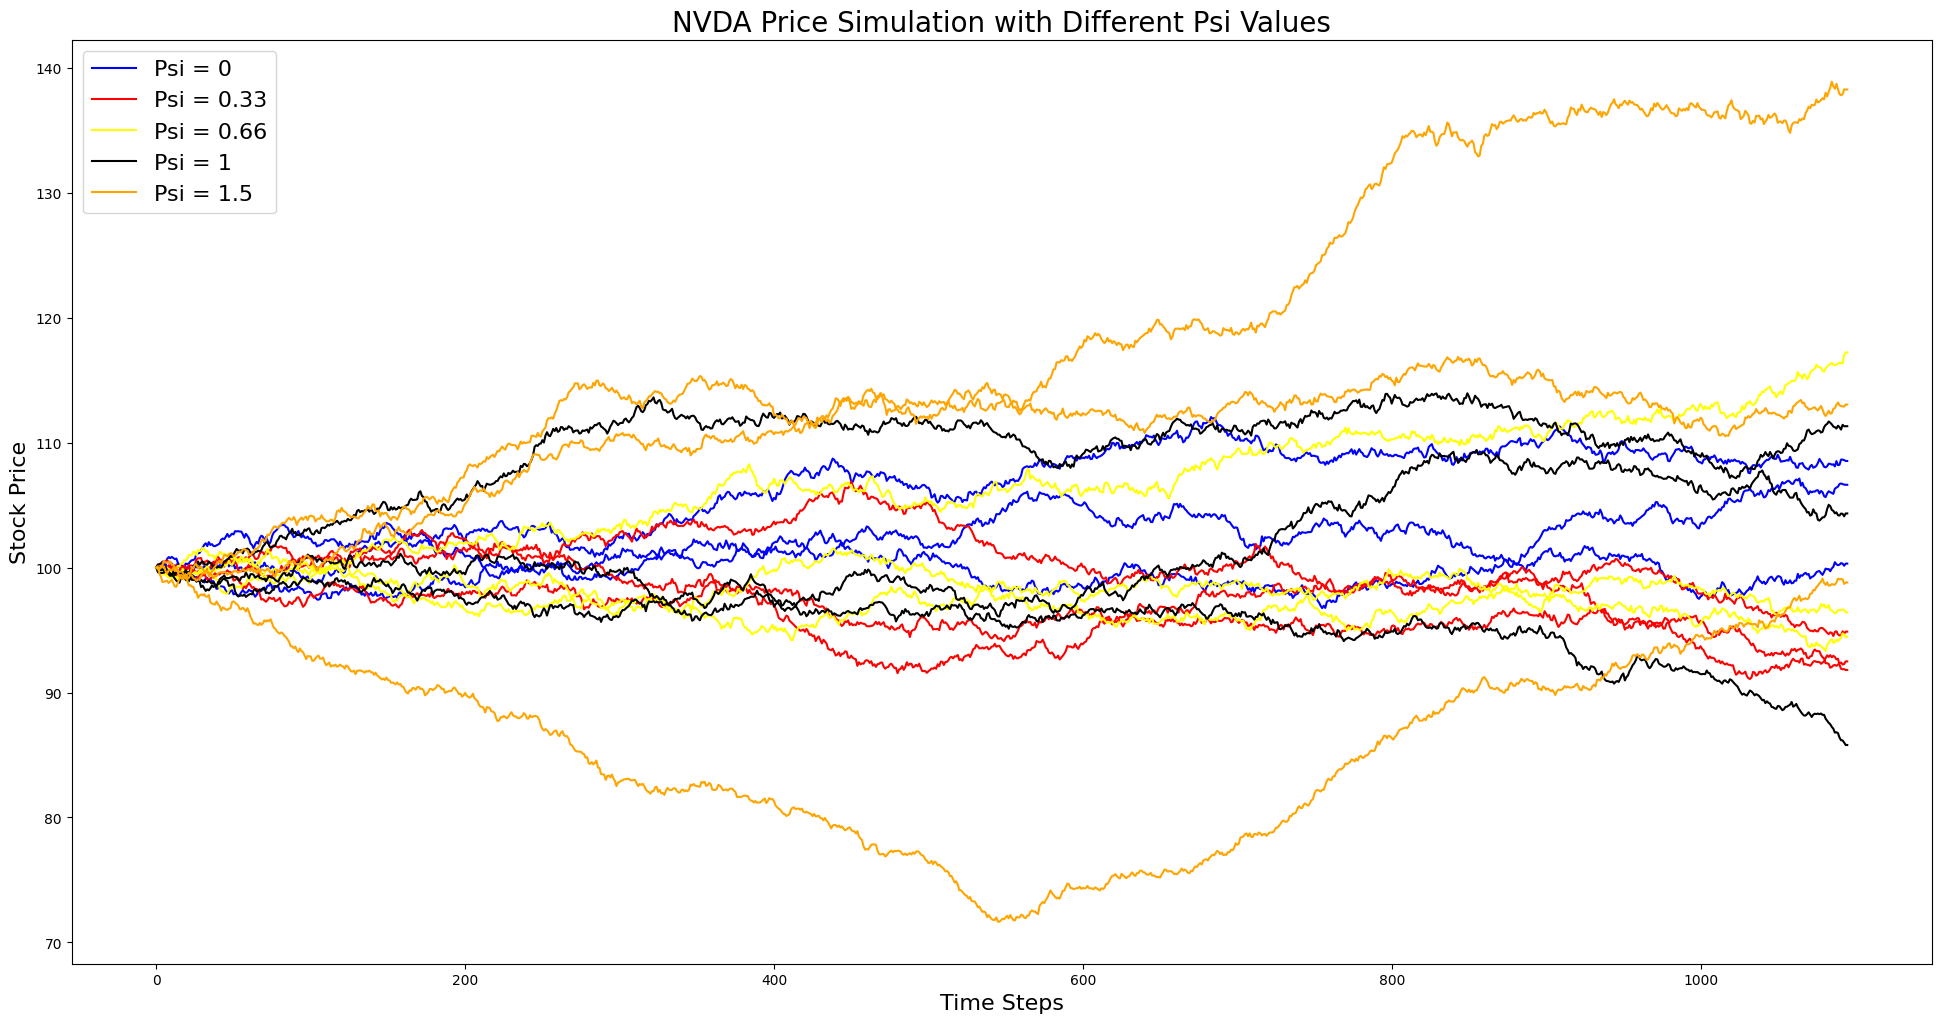

In [380]:
plt.subplots(figsize=(24,12))
plt.title('NVDA Price Simulation with Different Psi Values', fontsize=20)
plt.plot(S_NVDA_psi1.iloc[0], label='Psi = 0', color='blue')
plt.plot(S_NVDA_psi1.iloc[1], color='blue')
plt.plot(S_NVDA_psi1.iloc[2], color='blue')

plt.plot(S_NVDA_psi2.iloc[0], label='Psi = 0.33', color='red')
plt.plot(S_NVDA_psi2.iloc[1], color='red')
plt.plot(S_NVDA_psi2.iloc[2], color='red')

plt.plot(S_NVDA_psi3.iloc[0], label='Psi = 0.66', color='yellow')
plt.plot(S_NVDA_psi3.iloc[1], color='yellow')
plt.plot(S_NVDA_psi3.iloc[2], color='yellow')

plt.plot(S_NVDA_psi4.iloc[0], label='Psi = 1', color='black')
plt.plot(S_NVDA_psi4.iloc[1], color='black')
plt.plot(S_NVDA_psi4.iloc[2], color='black')

plt.plot(S_NVDA_psi5.iloc[0], label='Psi = 1.5', color='orange')
plt.plot(S_NVDA_psi5.iloc[1], color='orange')
plt.plot(S_NVDA_psi5.iloc[2], color='orange')

plt.xlabel('Time Steps', fontsize=16)
plt.ylabel('Stock Price', fontsize=16)
plt.legend(fontsize=16) 

In [383]:
NVDApsi_spx_0

,Time,Path,S,Delta,Cash,Portfolio_Value
0,0,0,100.000000,0.000000,0.000000,3000.000000
1,273,0,102.444040,30.820286,-50.012086,3023.309101
2,546,0,103.311849,30.266677,-87.659615,3037.315634
3,819,0,104.296293,30.000000,-100.000000,3041.360386
4,1095,0,100.153359,30.000000,-100.000000,2904.600769
5,0,1,100.000000,0.000000,0.000000,3000.000000
6,273,1,101.515256,30.820506,-50.012086,2995.445601
7,546,1,101.121979,30.281070,-87.282755,2970.784234
8,819,1,105.353007,30.000000,-100.000000,3073.875190
9,1095,1,109.632056,30.000000,-100.000000,3188.961691


In [384]:
NVDApsi_spx_033

,Time,Path,S,Delta,Cash,Portfolio_Value
0,0,0,100.000000,0.000000,0.000000,3000.000000
1,273,0,96.823096,30.821399,-50.012086,2854.680807
2,546,0,96.680800,30.338726,-85.422647,2835.775554
3,819,0,93.257577,30.000000,-100.000000,2711.743958
4,1095,0,92.000223,30.000000,-100.000000,2660.006698
5,0,1,100.000000,0.000000,0.000000,3000.000000
6,273,1,101.607532,30.820544,-50.012086,2998.213873
7,546,1,99.301405,30.285895,-87.310642,2915.468808
8,819,1,103.501407,30.000000,-100.000000,3018.297208
9,1095,1,101.887495,30.000000,-100.000000,2956.624863


In [386]:
NVDApsi_spx_066

,Time,Path,S,Delta,Cash,Portfolio_Value
0,0,0,100.000000,0.000000,0.000000,3000.000000
1,273,0,96.745088,30.821367,-50.012086,2852.340543
2,546,0,99.916235,30.327414,-85.399067,2934.097759
3,819,0,118.201408,30.817738,-100.000000,4306.194464
4,1095,0,118.698086,30.817638,742.639126,4303.581719
5,0,1,100.000000,0.000000,0.000000,3000.000000
6,273,1,104.206117,30.819886,-50.012086,3076.171427
7,546,1,103.306171,30.250818,-88.373083,3037.196912
8,819,1,105.849967,30.000000,-100.000000,3087.426161
9,1095,1,104.774057,30.000000,-100.000000,3043.221697


In [387]:
NVDApsi_spx_1

,Time,Path,S,Delta,Cash,Portfolio_Value
0,0,0,100.000000,0.000000,0.000000,3000.000000
1,273,0,98.832304,30.821099,-50.012086,2914.957047
2,546,0,107.000144,30.286569,-86.204728,3149.455649
3,819,0,109.765630,30.000000,-100.000000,3207.139616
4,1095,0,111.075056,30.000000,-100.000000,3232.251673
5,0,1,100.000000,0.000000,0.000000,3000.000000
6,273,1,111.529638,30.818807,-50.012086,4207.168952
7,546,1,112.854203,30.818653,820.032993,4205.659085
8,819,1,128.022745,30.816238,778.268852,6028.730363
9,1095,1,128.676259,30.816119,2140.186601,6000.474368


In [ ]:
NVDApsi_spx_15

In [369]:
psi_0_regime_stats

,down,mid,up
realised_vol,0.0,0.061664,0.0
mean_drift,0.0,0.000000,0.0
dwelling_time,0.0,1.000000,0.0
hit,0.0,1.000000,0.0


In [371]:
psi_033_regime_stats

,down,mid,up
realised_vol,0.0,0.061733,0.061927
mean_drift,0.0,0.000000,0.000000
dwelling_time,0.0,0.951598,0.048402
hit,0.0,1.000000,1.000000


In [370]:
psi_066_regime_stats

,down,mid,up
realised_vol,0.0,0.062604,0.0
mean_drift,0.0,0.000000,0.0
dwelling_time,0.0,1.000000,0.0
hit,0.0,1.000000,0.0


In [372]:
psi_1_regime_stats

,down,mid,up
realised_vol,0.0,0.064307,0.0
mean_drift,0.0,0.407894,0.0
dwelling_time,0.0,1.000000,0.0
hit,0.0,1.000000,0.0


In [373]:
psi_15_regime_stats

,down,mid,up
realised_vol,0.0,0.062285,0.0
mean_drift,0.0,0.669875,0.0
dwelling_time,0.0,1.000000,0.0
hit,0.0,1.000000,0.0


### SPX

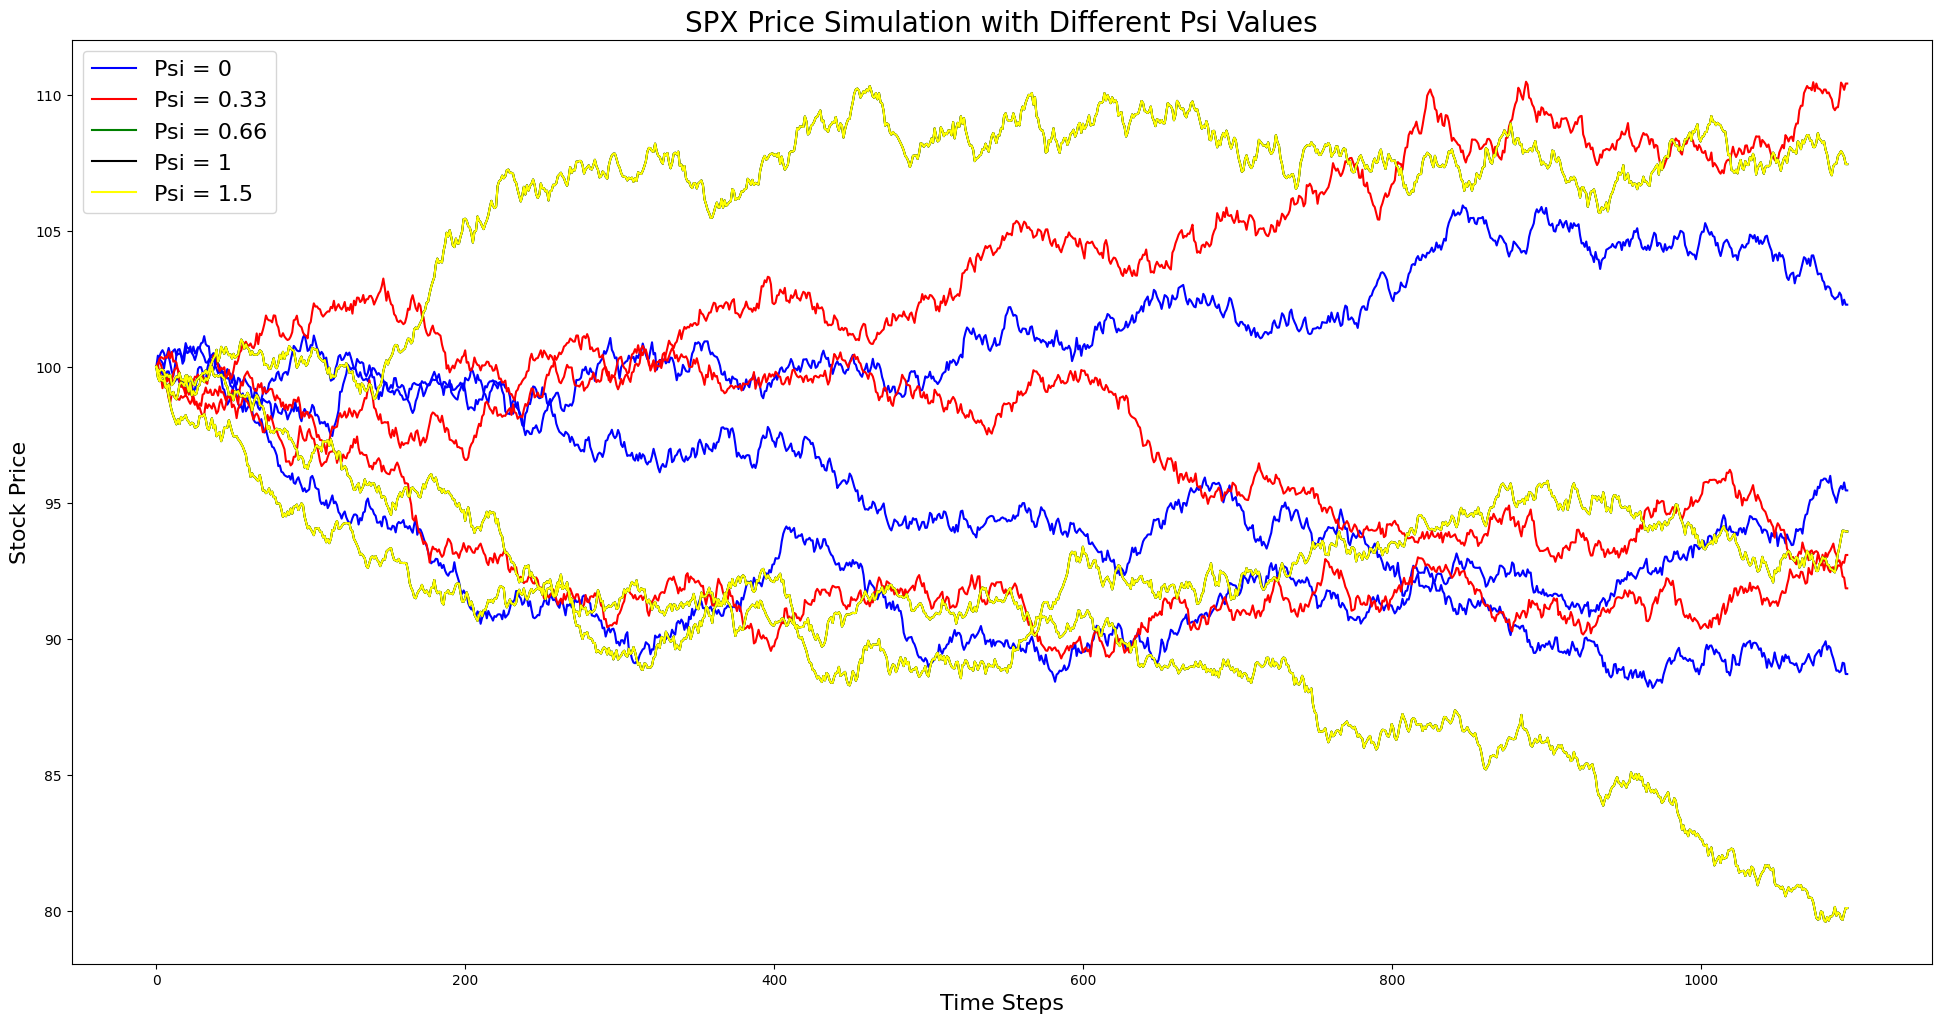

In [320]:
plt.subplots(figsize=(24,12))
plt.title('SPX Price Simulation with Different Psi Values', fontsize=20)
plt.plot(S_SPX_psi1.iloc[0], label='Psi = 0', color='blue')
plt.plot(S_SPX_psi1.iloc[1], color='blue')
plt.plot(S_SPX_psi1.iloc[2], color='blue')

plt.plot(S_SPX_psi2.iloc[0], label='Psi = 0.33', color='red')
plt.plot(S_SPX_psi2.iloc[1], color='red')
plt.plot(S_SPX_psi2.iloc[2], color='red')

plt.plot(S_SPX_psi3.iloc[0], label='Psi = 0.66', color='green')
plt.plot(S_SPX_psi3.iloc[1], color='green')
plt.plot(S_SPX_psi3.iloc[2], color='green')

plt.plot(S_SPX_psi3.iloc[0], label='Psi = 1', color='black')
plt.plot(S_SPX_psi3.iloc[1], color='black')
plt.plot(S_SPX_psi3.iloc[2], color='black')

plt.plot(S_SPX_psi3.iloc[0], label='Psi = 1.5', color='yellow')
plt.plot(S_SPX_psi3.iloc[1], color='yellow')
plt.plot(S_SPX_psi3.iloc[2], color='yellow')

plt.xlabel('Time Steps', fontsize=16)
plt.ylabel('Stock Price', fontsize=16)
plt.legend(fontsize=16)


In [324]:
psi_spx_0

,Time,Path,S,Delta,Cash,Portfolio_Value
0,0,0,100.000000,0.000000,0.000000,3000.000000
1,273,0,101.112948,22.569380,2.498523,3042.725946
2,546,0,102.220941,22.571004,5.918008,3079.461247
3,819,0,98.856247,22.580715,9.375511,2981.756628
4,1095,0,98.239856,22.581242,12.722365,2966.570366
5,0,1,100.000000,0.000000,0.000000,3000.000000
6,273,1,97.734493,22.585768,2.498523,2941.154313
7,546,1,90.165418,22.631157,5.809019,2716.906458
8,819,1,89.569017,22.637694,8.876463,2702.045067
9,1095,1,89.400054,22.625836,11.925511,2700.006870


In [325]:
psi_spx_033

,Time,Path,S,Delta,Cash,Portfolio_Value
0,0,0,100.000000,0.000000,0.000000,3000.000000
1,273,0,110.405390,22.530313,2.498523,3322.099130
2,546,0,117.220477,22.499831,6.217974,3530.706462
3,819,0,118.590347,22.497585,10.155064,3575.829868
4,1095,0,124.384723,22.475852,14.137267,3754.014264
5,0,1,100.000000,0.000000,0.000000,3000.000000
6,273,1,100.456898,22.571630,2.498523,3023.001546
7,546,1,97.025316,22.587628,5.896566,2923.230184
8,819,1,102.547528,22.561063,9.183632,3092.539856
9,1095,1,106.751031,22.549391,12.648820,3222.385959


In [326]:
psi_spx_066

,Time,Path,S,Delta,Cash,Portfolio_Value
0,0,0,100.000000,0.000000,0.000000,3000.000000
1,273,0,99.763511,22.577771,2.498523,3002.157047
2,546,0,103.522474,22.558750,5.875127,3118.544025
3,819,0,106.640778,22.544507,9.372468,3215.791132
4,1095,0,105.749567,22.547423,12.970126,3192.594373
5,0,1,100.000000,0.000000,0.000000,3000.000000
6,273,1,105.844691,22.551706,2.498523,3184.985907
7,546,1,112.517354,22.522129,6.071850,3389.167526
8,819,1,114.378495,22.512254,9.859380,3448.907024
9,1095,1,112.664112,22.522261,13.705782,3401.214189


In [328]:
psi_spx_1

,Time,Path,S,Delta,Cash,Portfolio_Value
0,0,0,100.000000,0.000000,0.000000,3000.000000
1,273,0,97.407311,22.588210,2.498523,2931.318235
2,546,0,95.182965,22.595207,5.798716,2867.741676
3,819,0,90.065891,22.622698,9.025727,2717.125647
4,1095,0,79.111332,22.692787,12.087318,3223.780141
5,0,1,100.000000,0.000000,0.000000,3000.000000
6,273,1,95.837428,22.593932,2.498523,2884.118957
7,546,1,105.932164,22.548545,5.747323,3190.862580
8,819,1,100.485269,22.571980,9.322494,3030.678806
9,1095,1,104.820448,22.557710,12.721613,3164.416709


In [329]:
psi_spx_15

,Time,Path,S,Delta,Cash,Portfolio_Value
0,0,0,100.000000,0.000000,0.000000,3000.000000
1,273,0,110.439284,22.530799,2.498523,3323.118599
2,546,0,109.723442,22.528355,6.219295,3305.314087
3,819,0,104.044710,22.557084,9.915056,3138.285188
4,1095,0,106.739588,22.547022,13.429467,3222.820866
5,0,1,100.000000,0.000000,0.000000,3000.000000
6,273,1,91.365086,22.621369,2.498523,2749.661811
7,546,1,100.134348,22.568940,5.603882,3016.406805
8,819,1,89.875042,22.627527,8.990128,2711.354419
9,1095,1,106.158008,2001.629962,12.046638,7807.565279


In [355]:
SPX_psi_0_regime_stats

,down,mid,up
realised_vol,0.0,0.064973,0.0
mean_drift,0.0,0.000000,0.0
dwelling_time,0.0,1.000000,0.0
hit,0.0,1.000000,0.0


In [356]:
SPX_psi_033_regime_stats

,down,mid,up
realised_vol,0.0,0.061078,0.0
mean_drift,0.0,0.000000,0.0
dwelling_time,0.0,1.000000,0.0
hit,0.0,1.000000,0.0


In [358]:
SPX_psi_066_regime_stats

,down,mid,up
realised_vol,0.069586,0.063482,0.0
mean_drift,0.000000,0.000000,0.0
dwelling_time,0.408219,0.591781,0.0
hit,1.000000,1.000000,0.0


In [360]:
SPX_psi_1_regime_stats

,down,mid,up
realised_vol,0.0,0.063467,0.0
mean_drift,0.0,2.098314,0.0
dwelling_time,0.0,1.000000,0.0
hit,0.0,1.000000,0.0


In [361]:
SPX_psi_15_regime_stats

,down,mid,up
realised_vol,0.0,0.063546,0.0
mean_drift,0.0,-1.388806,0.0
dwelling_time,0.0,1.000000,0.0
hit,0.0,1.000000,0.0


### Question 12

Given the stock price dynamics are order flow driven, we can benefit from the predictablility of the underlying price and take positions depending on what regime/dynamics are, and what the market makers must do to remain hedged.

If the stock is trading below the put strike, we know when the market maker is short gamma, they will need to sell the underlying in order to remain delta-hedged. This will exert further downward pressure on the stock. From Question 11, we know this exhibits a period of high volatility within a short-period of time. An ideal trade in this scenario would be to take a bearish position either via buying puts or out right shorting the underlying (where this depends on the impact our AUM has on the market and the overall hedging-dependent drift)

If the stock is trading between the strikes, and the market maker is relatively flat on gamma, the market as observed is likely to be stickier, which could allow us to benefit from call overwriting strategies and/or selling protective puts (depending on if we have a directional view)

Finally, if the stock is trading beyond the higher call-strike and the market maker is long-gamma, this tends to result in the typical pinning/gamma-squeeze. This is almost opposite to the first scenario when the market maker is short-gamma and the underlying is below the first strike. Now the market maker will most likely buy the underlying to remain delta-flat, which further contributes to the upwards momentum. This again is typically the most exaggerated towards the strike expiry date and also has a typically short mean dwelling time. Here, our AUM can impact the market driving upwards the price, contributing to even more buying pressure and increasing the likelihood of our strategy being successful.


Strategy description :

There are five strategies that we can run, and this is depending on what 'zone' we are currently experiencing in and also if the regional statistics (volatility richness e.g., realised vol disrepencies with respect to implied volatility used to price options) calculated in Q11 are favourable for a given strategy. The five strategies are 
1. Buy long puts that are OTM when we are in a 'down' zone and implied volatility is cheap relative to realised volatility. This is a long vega position and will also result in us taking a short delta position.
2. Buy ATM straddles (bet on volatility) which results in a pure vega and no delta exposure. This strategy works in the middle zone when volatility is low as we know this is the zone where market makers typically are the most quiet (regardless of their gamma exposure, if the underlying is still they will not create large feedback effects)
3. Sell OTM puts when are are in a 'down' zone but this time when implied volatility is expensive relative to realised volatility. This is the opposite of strategy 1 giving us a negative vega exposure. But this strategy profits off the OTM puts being more expensive and netting the premium. This is also a long theta play for us.
4. Ride the gamma-squeeze when we are in an 'up' zone and implied volatility is cheap. As market makers buy more underlying to remain hedged (when they are short-gamma) that drives prices up, we can profit from the upward feedback and elevated volatility. 
5. Call overwrite when we are in an 'up' zone but the implied volatility does not justify the market price of call options. We can sell calls to profit from the expensive implied volatility. Keeping underlying shares of stocks also ensures we do not get steamrolled 'picking up pennies in front of a streamroller'.

We defined the following limits as
1. Expensive/cheap implied volatility is 10% or more from realised volatility
2. h' is 3x the original dt time steps (e.g., trading ~2 a week if dt = 8 hours (how long the market is open for a day))
3. Position limit is capped at 5% of delta => this is monitored by ensuring the delta exposure does not go above e.g., 15%. This parameter will depend on what value of w0 we set.
4. Vega limit also limits our exposure to options specifically, preventing potential trade implosions given the high tail risk environment and also margin call considerations. Since we can trade in the underlying as well, this helps create rules for when we trade in each asset class. 

In [278]:
w = 1000000 #AUM 
CFG = dict(
    max_delta_frac = 0.4,      # |Δ| limit as fraction of NAV
    max_vega_frac  = 0.2,      # |vega| limit
    hprime_steps   = 3,        # trade only every h' steps (e.g. 4h if dt=10 min)
    cheap_IV_mult  = 0.90,      # IV < 0.9×realised ⇒ vol is cheap
    rich_IV_mult   = 1.10       # IV > 1.1×realised ⇒ vol is rich
)


In [279]:
# ---------------------- Support/Helping Functions for Q12-------------------------
'''

This function helps us understand the sizes we will take at each point in time. 
Includes limits on delta and vega exposures as well
Output is our target deltas and vegas at each point in time'

'''

def position_rules(zone, IV, RV, w, S,
                   max_delta, max_vega):
    if zone == 'up' and IV < CFG['cheap_IV_mult']*RV:
        # ride gamma squeeze 
        delta =  0.05*w/S
        vega  =  0.0
    elif zone == 'up':
        # gamma-scalp (short call, reduced long Δ)
        delta =  0.02*w/S
        vega  = -0.02*w
    elif zone == 'mid' and IV < CFG['cheap_IV_mult']*RV:
        # long cheap vol
        delta = 0.0
        vega  = 0.02*w
    elif zone == 'down' and IV < CFG['cheap_IV_mult']*RV:
        # buy protective puts
        delta = -0.03*w/S
        vega  =  0.03*w
    elif zone == 'down':
        # sell expensive puts
        delta = -0.01*w/S
        vega  = -0.02*w
    else:
        delta = vega = 0.0

    # enforce limits
    delta = np.clip(delta, -max_delta, max_delta)
    vega  = np.clip(vega,  -max_vega,  max_vega)
    return delta, vega

"""
Return 'down' / 'mid' / 'up' for each step => this lets us know what zone 
we are in which is used in the back-test

"""

def classify_zone(S, K_put, K_call):
    return np.where(S < K_put, 'down',
           np.where(S > K_call, 'up',  'mid'))

In [289]:
def run_fbi_strategy(S_path,    
                     K_put_arr, 
                     K_call_arr,
                     IV_path,  
                     dt,
                     w0=w,
                     r=0.0):
    
    T = len(S_path) - 1
    zone = classify_zone(S_path[:-1], K_put_arr[:-1], K_call_arr[:-1])

    # Create our records for delta, vega exposures, NAV and trade deltas
    nav   = np.full(T+1, w0, dtype=float)
    delta = np.zeros(T+1)       # our underlying position size
    vega  = np.zeros(T+1)       # not priced → track exposure only
    trade_delta = np.zeros(T+1)

    # realised vol running estimator (just using an EWMA - can use GARCH)
    rv = np.zeros(T+1); rv[0] = IV_path[0] if np.ndim(IV_path)>0 else IV_path
    alpha = 0.01                # EWMA decay

    max_delta = CFG['max_delta_frac']*w0/S_path[0]
    max_vega  = CFG['max_vega_frac'] *w0

    for t in range(T):
        # update realised vol (EMWA)
        rv[t] = (1-alpha)*rv[t-1] + alpha*abs(np.log(S_path[t+1]/S_path[t]))/np.sqrt(dt)

        # trade every h' steps OR if zone changes
        if (t % CFG['hprime_steps'] == 0) or (zone[t] != zone[t-1] if t else True):
            IV = IV_path[t] if np.ndim(IV_path)>0 else IV_path
            d_target, v_target = position_rules(zone[t], IV, rv[t],
                                                nav[t], S_path[t],
                                                max_delta, max_vega)
            # adjust delta position
            trade_delta[t] = d_target - delta[t]
            delta[t+1] = d_target
            vega [t+1] = v_target
        else:
            # carry positions forward
            delta[t+1] = delta[t]
            vega [t+1] = vega [t]

        # P&L from delta position over (t,t+1]
        nav[t+1] = nav[t] + delta[t]*(S_path[t+1]-S_path[t]) + nav[t]*r*dt

    return pd.DataFrame({
        'S'     : S_path,
        'zone'  : np.append(zone, zone[-1]),
        'NAV'   : nav,
        'delta' : delta,
        'vega'  : vega,
        'trader_delta': trade_delta
    })

## Q12 for SPX

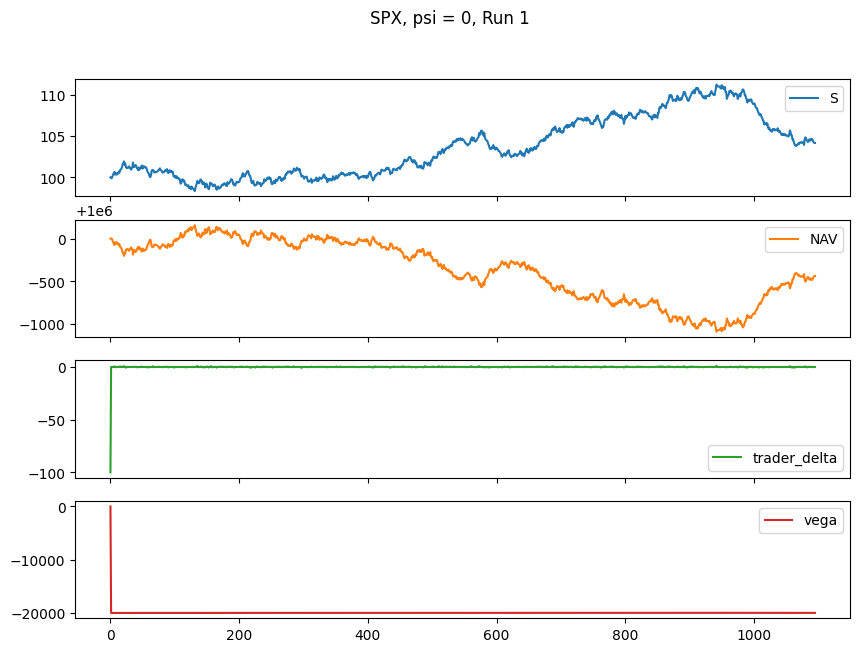

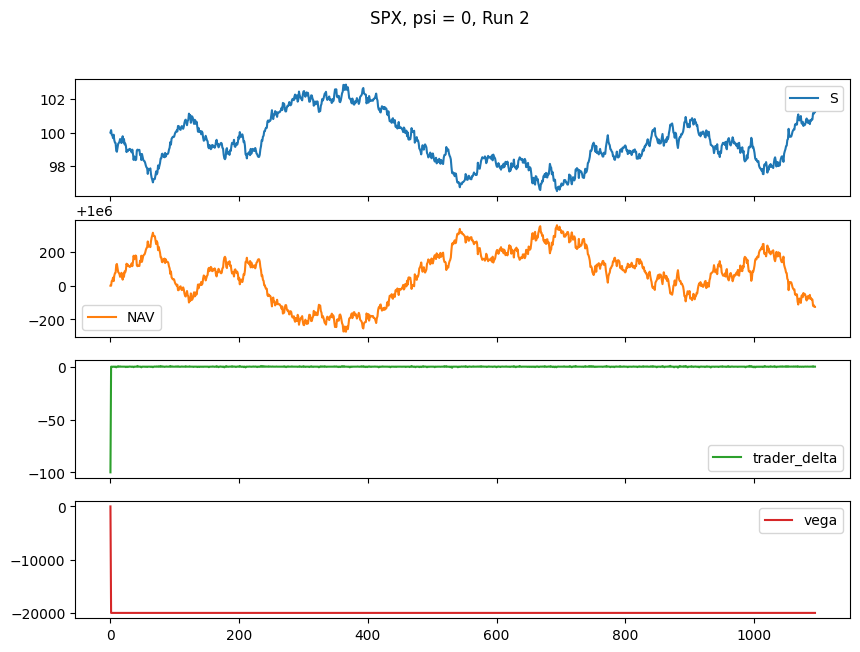

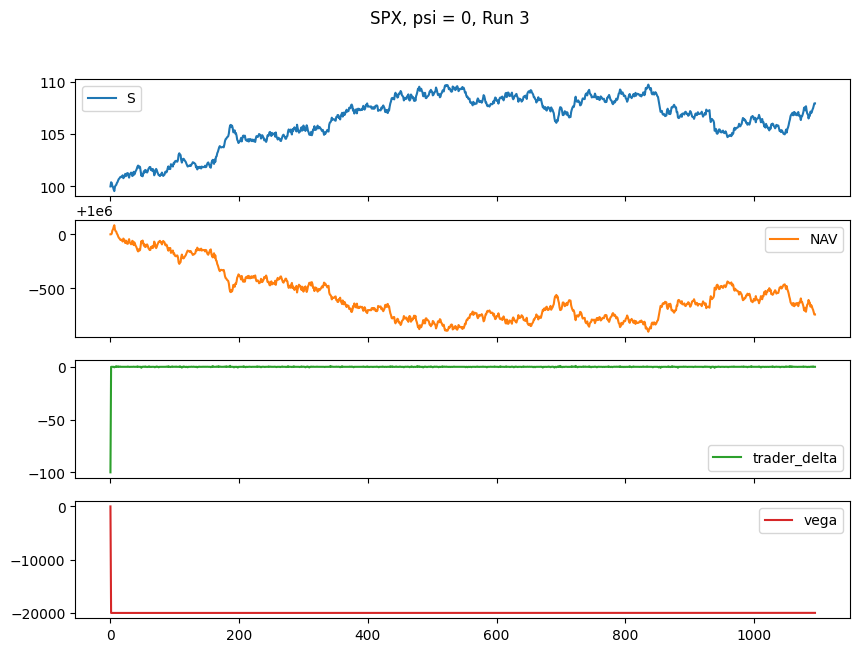

In [295]:
#SPX, psi = 0
for i in range(len(S_SPX_psi1)):
    result_SPX_psi1 = run_fbi_strategy(
                S_path      = S_SPX_psi1.iloc[i],   # ndarray T+1
                K_put_arr   = expand_strikes(strike_call_SPX1.iloc[i], opex_indices, N),
                K_call_arr  = expand_strikes(strike_put_SPX1.iloc[i], opex_indices, N),
                IV_path     = sigma,    # or scalar σ_IV
                dt          = dt,
                w0          = w
)
    result_SPX_psi1[['S','NAV','trader_delta', 'vega']].plot(subplots=True, figsize=(10,7), title =f'SPX, psi = 0, Run {i+1}')


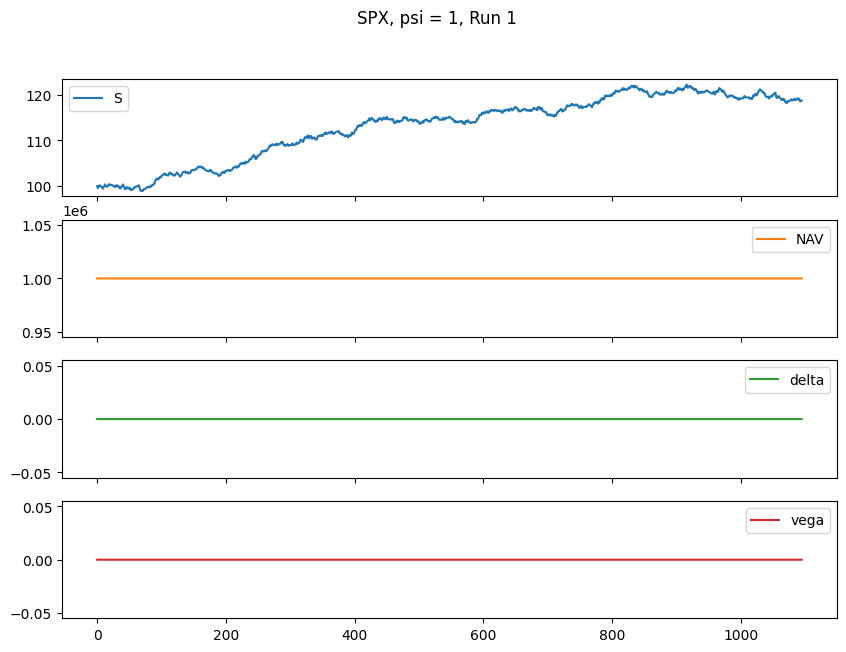

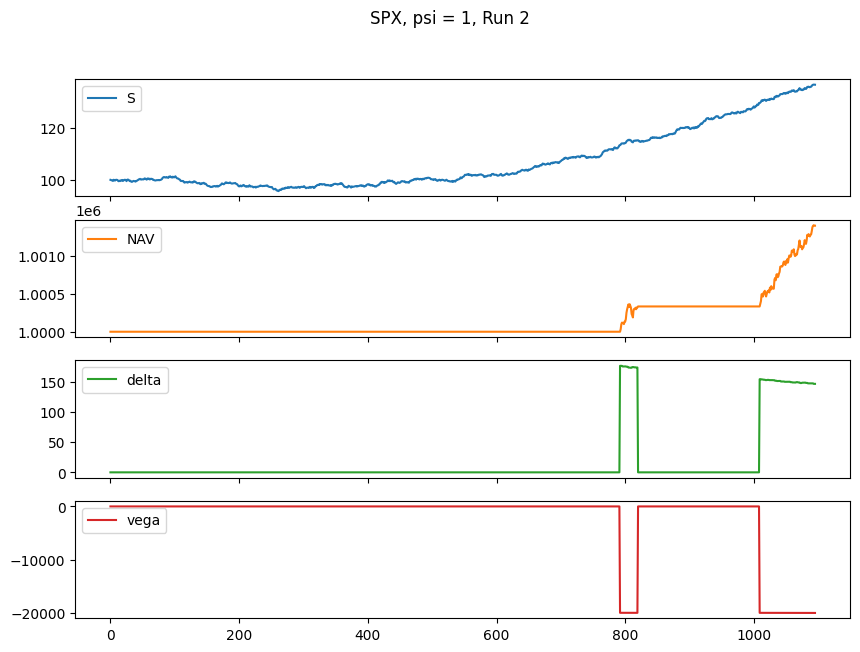

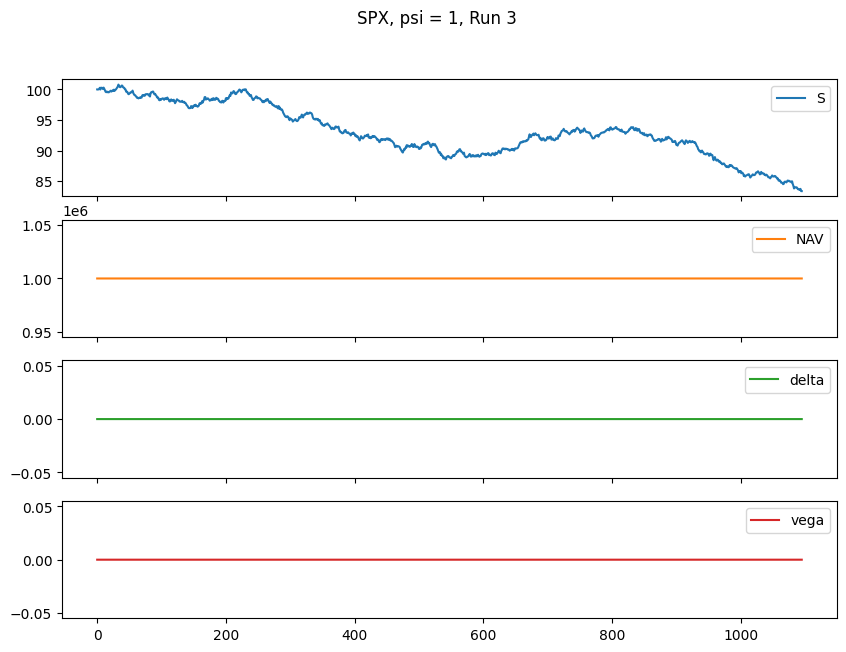

In [294]:
#SPX, psi = 1

for i in range(len(S_SPX_psi1)):
    result_SPX_psi2 = run_fbi_strategy(
                S_path      = S_SPX_psi2.iloc[i],   # ndarray T+1
                K_put_arr   = expand_strikes(strike_put_SPX2.iloc[i], opex_indices, N),
                K_call_arr  = expand_strikes(strike_call_SPX2.iloc[i], opex_indices, N),
                IV_path     = sigma,    # or scalar σ_IV
                dt          = dt,
                w0          = w
)
    result_SPX_psi2[['S','NAV','delta', 'vega']].plot(subplots=True, figsize=(10,7), title =f'SPX, psi = 1, Run {i+1}')


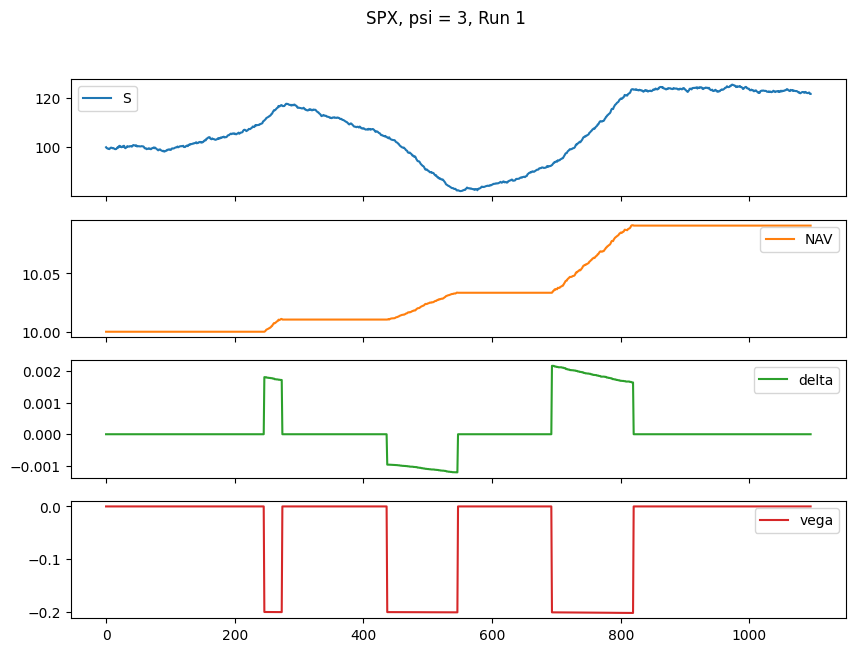

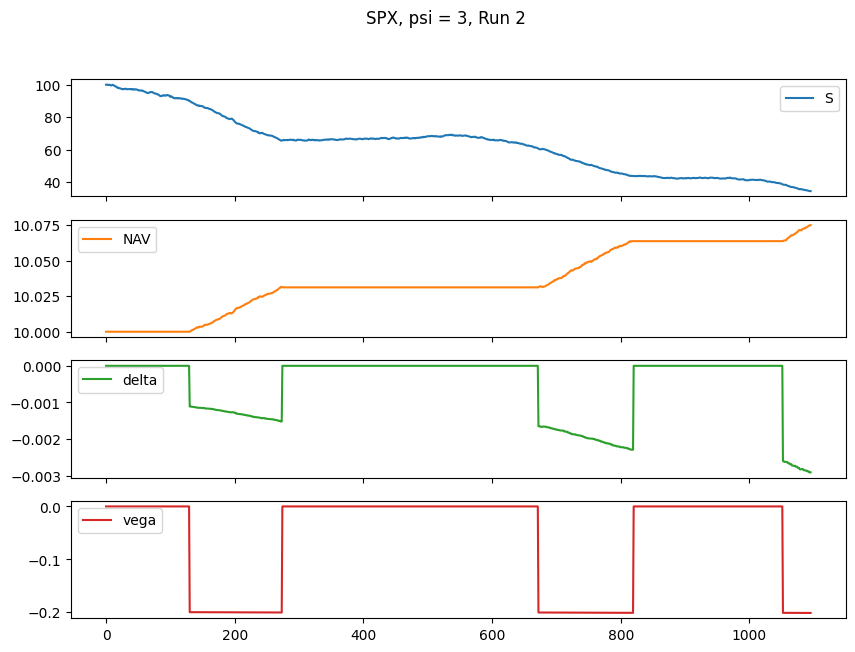

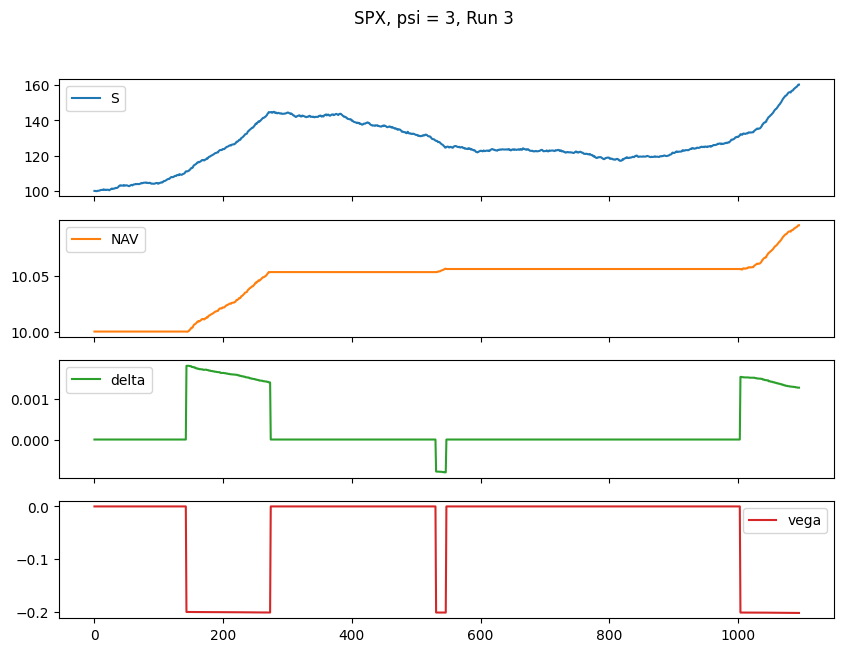

In [296]:
#SPX, psi = 3

for i in range(len(S_SPX_psi1)):
    result_SPX_psi3 = run_fbi_strategy(
                S_path      = S_SPX_psi3.iloc[i],   # ndarray T+1
                K_put_arr   = expand_strikes(strike_put_SPX3.iloc[i], opex_indices, N),
                K_call_arr  = expand_strikes(strike_call_SPX3.iloc[i], opex_indices, N),
                IV_path     = sigma,    # or scalar σ_IV
                dt          = dt,
                w0          = w0
)
    result_SPX_psi3[['S','NAV','delta','vega']].plot(subplots=True, figsize=(10,7) , title =f'SPX, psi = 3, Run {i+1}')



## Q12 for NVDA

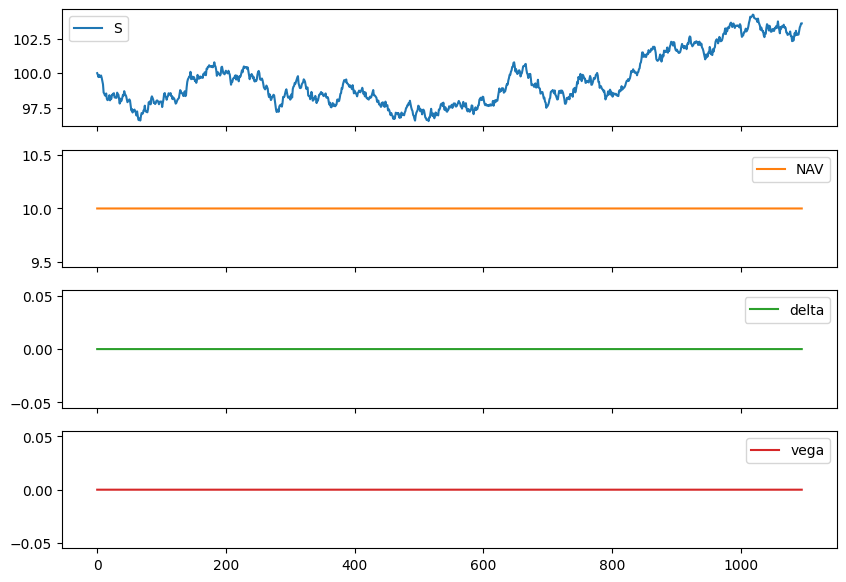

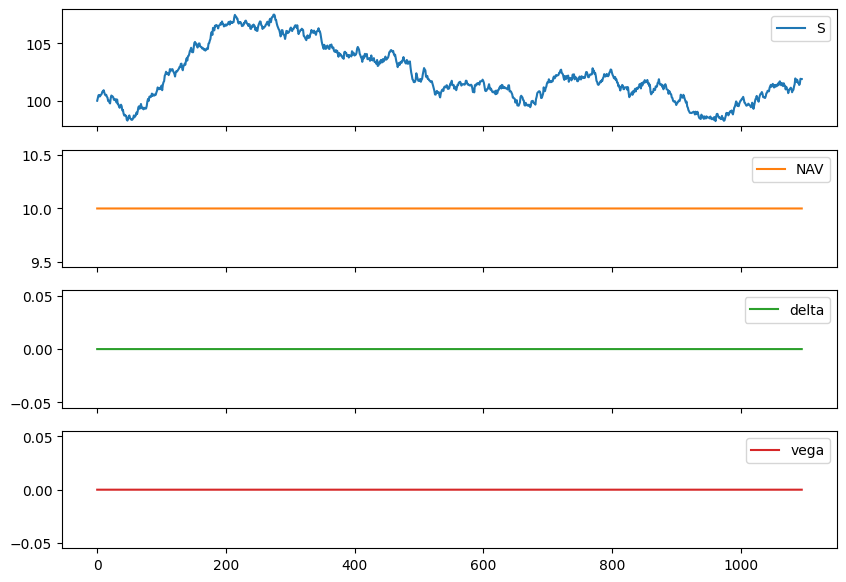

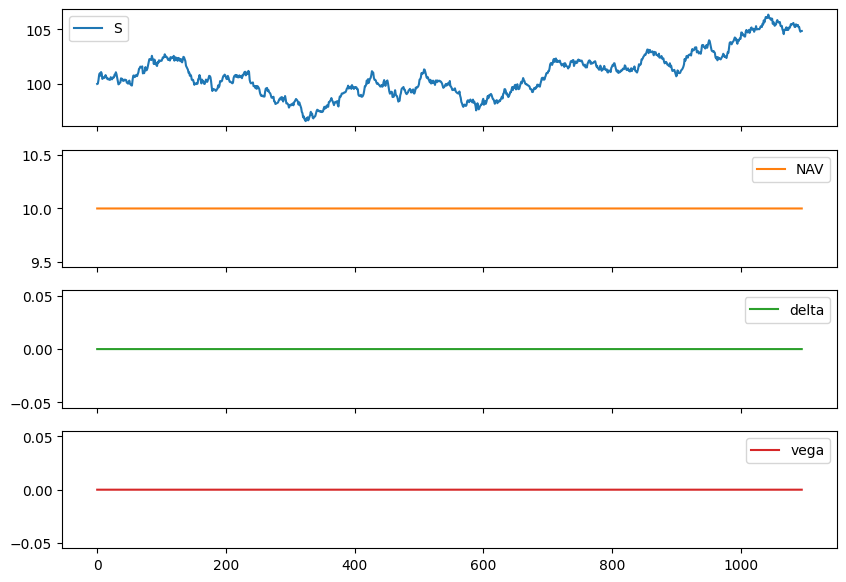

In [297]:
#NVDA, psi = 0

for i in range(len(S_NVDA_psi1)):
    result_NVDA_psi0 = run_fbi_strategy(
                S_path      = S_NVDA_psi1.iloc[i],   # ndarray T+1
                K_put_arr   = expand_strikes(strike_put_psi1.iloc[i], opex_indices, N),
                K_call_arr  = expand_strikes(strike_call_psi1.iloc[i], opex_indices, N),
                IV_path     = sigma,    # or scalar σ_IV
                dt          = dt,
                w0          = w0
)
    result_NVDA_psi0[['S','NAV','delta', 'vega']].plot(subplots=True, figsize=(10,7))


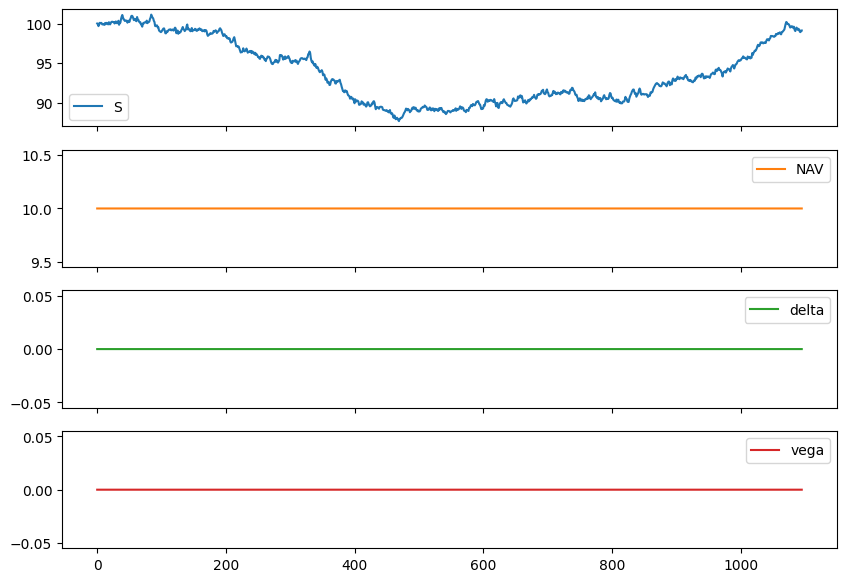

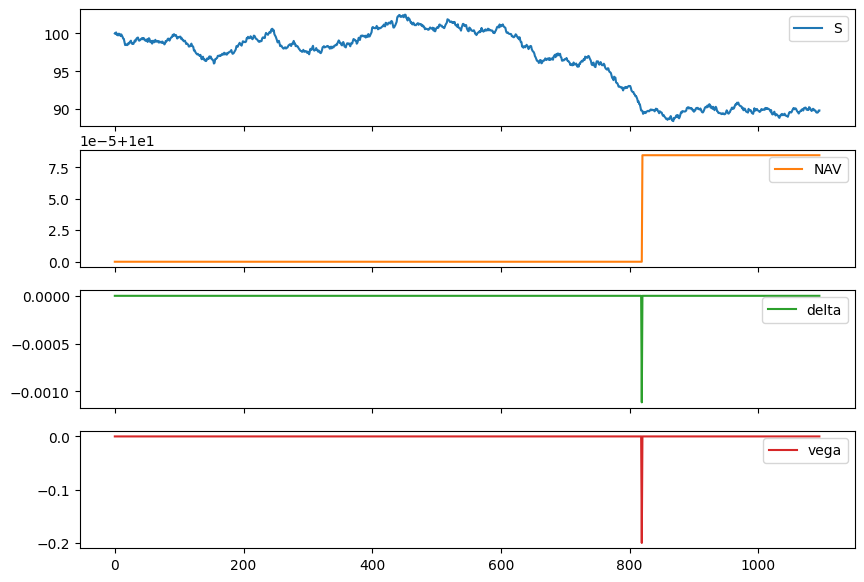

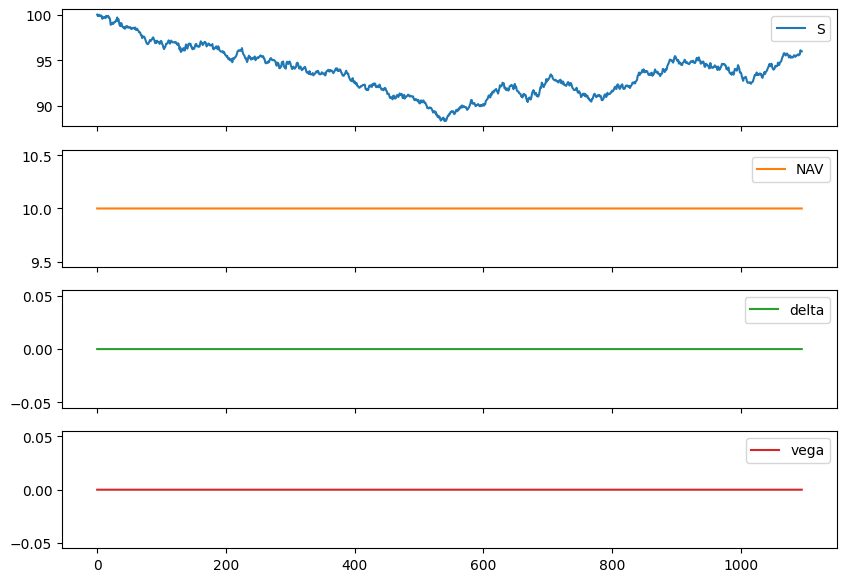

In [300]:
#NVDA, psi = 1

for i in range(len(S_NVDA_psi1)):
    result_NVDA_psi1 = run_fbi_strategy(
                S_path      = S_NVDA_psi2.iloc[i],   # ndarray T+1
                K_put_arr   = expand_strikes(strike_put_psi2.iloc[i], opex_indices, N),
                K_call_arr  = expand_strikes(strike_call_psi2.iloc[i], opex_indices, N),
                IV_path     = sigma,    # or scalar σ_IV
                dt          = dt,
                w0          = w0
)
    result_NVDA_psi1[['S','NAV','delta','vega']].plot(subplots=True, figsize=(10,7))


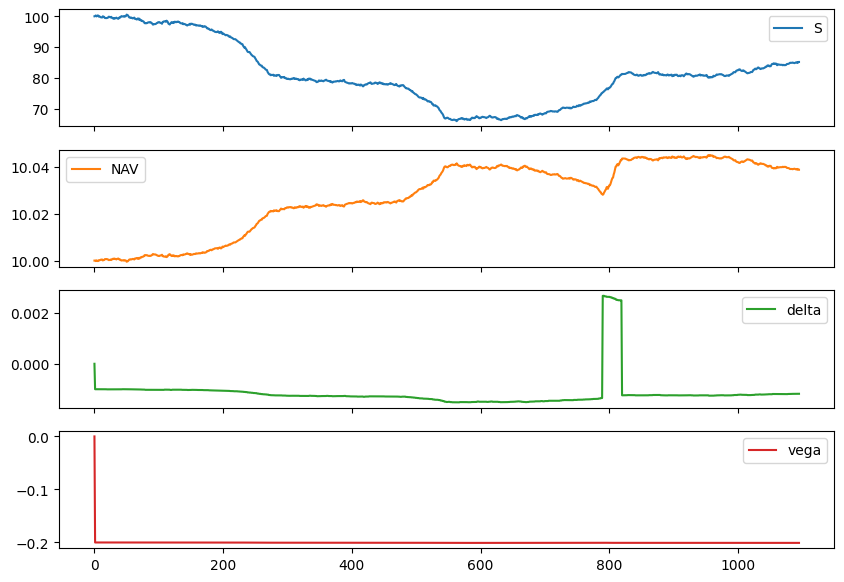

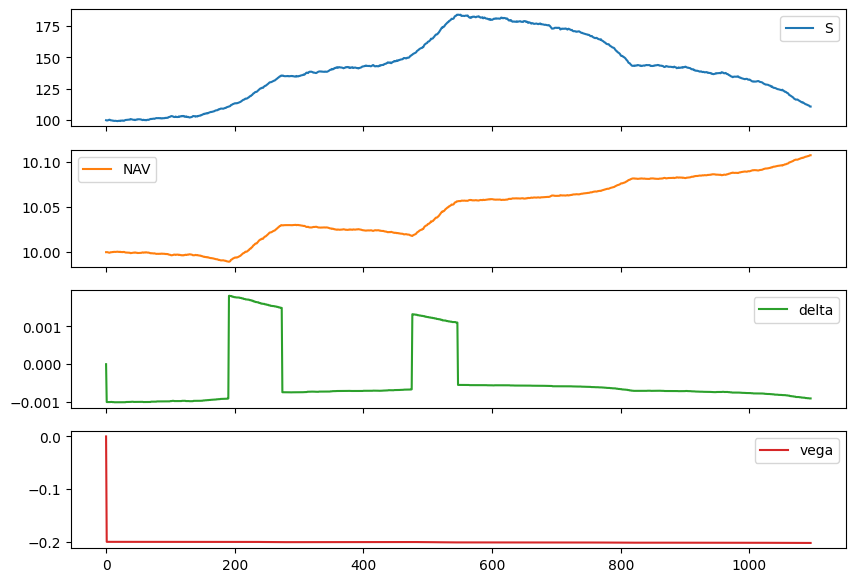

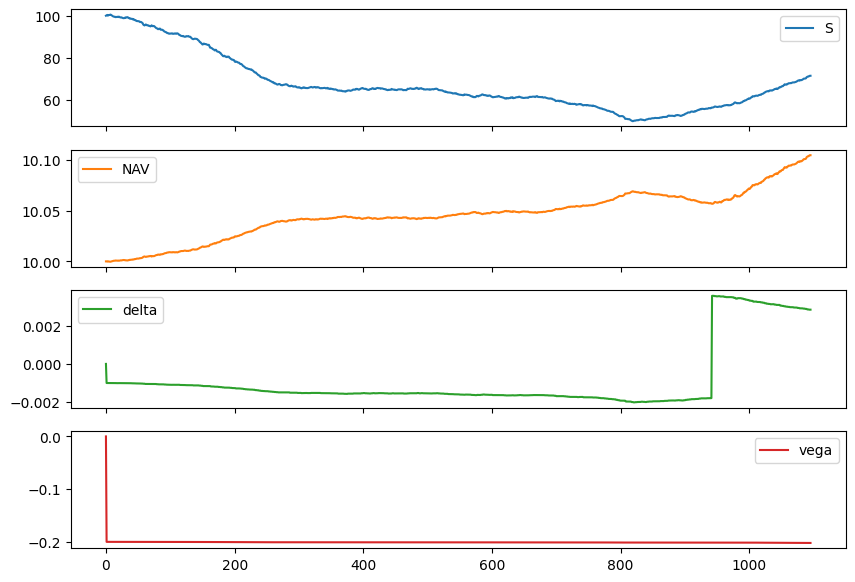

In [302]:
#NVDA, psi = 3

for i in range(len(S_NVDA_psi1)):
    result_NVDA_psi3 = run_fbi_strategy(
                S_path      = S_NVDA_psi3.iloc[i],   # ndarray T+1
                K_put_arr   = expand_strikes(strike_call_psi3.iloc[i], opex_indices, N),
                K_call_arr  = expand_strikes(strike_put_psi3.iloc[i], opex_indices, N),
                IV_path     = sigma,    # or scalar σ_IV
                dt          = dt,
                w0          = w0
)
    result_NVDA_psi3[['S','NAV','delta', 'vega']].plot(subplots=True, figsize=(10,7))


When estimating these statistics, use different sampling frequencies, especially those lower (less frequent) than the dt = h you have chosen that sets the step size (why?)

Rebalancing at larger time steps means less frequent rebalancing. This results in us locking in our profits at bigger intervals which effectively means we 'make less bets'. We can miss out on more profit-taking and/or loss making opportunities. In a higher volatility environment where mean dwelling time in a favourable zone is short, we can potentially miss out on higher gains. In the middle volatility environment, where for example call overwriting strategies is used, this longer timeframe to sell calls can also result in us having to buy/sell less to achieve the same returns can mean we pay less transaction fees. 